✅ Found data at: /kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas/imagesTr
📊 Files found: 281


I0000 00:00:1774468789.094249     117 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



🚀 Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1774468798.497162     160 service.cc:152] XLA service 0x1ba94100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774468798.497197     160 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774468799.044969     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/224 ━━━━━━━━━━━━━━━━━━━━ 26:02 7s/step - accuracy: 0.5000 - loss: 0.7300

I0000 00:00:1774468801.930965     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


224/224 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.6485 - loss: 0.6121 - val_accuracy: 0.8158 - val_loss: 0.5671
Epoch 2/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.8059 - loss: 0.5206 - val_accuracy: 0.8421 - val_loss: 0.3556
Epoch 3/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.8604 - loss: 0.3498 - val_accuracy: 0.8596 - val_loss: 0.3685
Epoch 4/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.8588 - loss: 0.3589 - val_accuracy: 0.8947 - val_loss: 0.2984
Epoch 5/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.8725 - loss: 0.3340 - val_accuracy: 0.8772 - val_loss: 0.2890

📊 Evaluating...


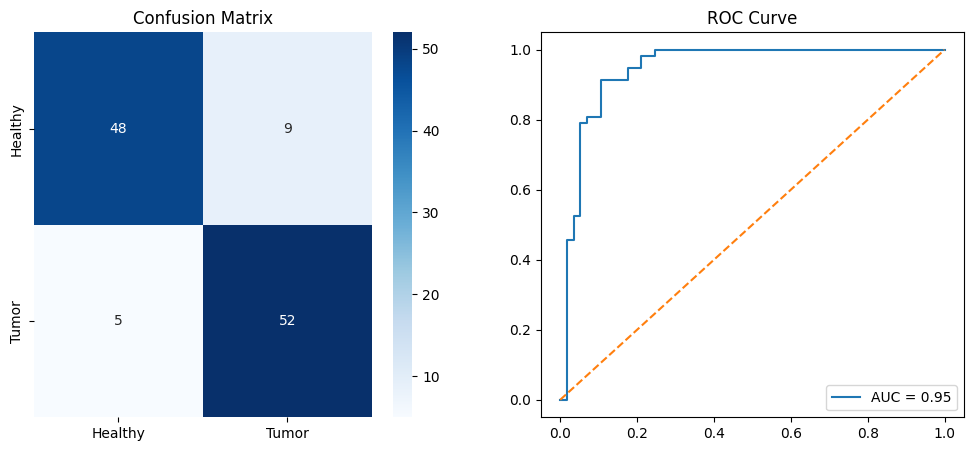

              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87        57
         1.0       0.85      0.91      0.88        57

    accuracy                           0.88       114
   macro avg       0.88      0.88      0.88       114
weighted avg       0.88      0.88      0.88       114



In [5]:
import os
import gc
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, Conv3DTranspose, Add, PReLU, GlobalAveragePooling3D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. SETTINGS & PATHS ---
PATCH_SIZE = 32  
BATCH_SIZE = 1  

# Improved path detection
try:
    # Look for the folder that ACTUALLY contains .nii or .gz files
    potential_dirs = glob.glob('/kaggle/input/**/imagesTr', recursive=True)
    IMAGE_DIR = potential_dirs[0]
    MASK_DIR = IMAGE_DIR.replace('imagesTr', 'labelsTr')
    print(f"✅ Found data at: {IMAGE_DIR}")
except IndexError:
    raise FileNotFoundError("Could not find 'imagesTr' folder. Is the dataset attached?")

# --- 2. DATA GENERATOR ---
class VNetSequence(Sequence):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]
        mask_path = os.path.join(MASK_DIR, f)
        img_path = os.path.join(IMAGE_DIR, f)
        
        mask_obj = nib.load(mask_path)
        mask_data = mask_obj.get_fdata()
        
        t_vox = np.argwhere(mask_data == 2)
        h_vox = np.argwhere(mask_data == 0)
        
        X, y = [], []
        
        def extract_patch(center, label):
            img_obj = nib.load(img_path)
            z, yc, xc = [int(c) for c in center]
            zs, ys, xs = max(0, z-PATCH_SIZE//2), max(0, yc-PATCH_SIZE//2), max(0, xc-PATCH_SIZE//2)
            p = np.array(img_obj.dataobj[zs:zs+PATCH_SIZE, ys:ys+PATCH_SIZE, xs:xs+PATCH_SIZE])
            if p.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                p = np.pad(p, [(0, PATCH_SIZE-s) for s in p.shape])
            p = (np.clip(p, -100, 200) + 100) / 300.0
            X.append(p[..., np.newaxis])
            y.append(label)

        if len(t_vox) > 0:
            extract_patch(t_vox[len(t_vox)//2], 1)
        if len(h_vox) > 0:
            extract_patch(h_vox[np.random.choice(len(h_vox))], 0)
            
        del mask_data
        gc.collect()
        return np.array(X, dtype='float32'), np.array(y, dtype='float32')

# --- 3. V-NET ARCHITECTURE ---
def build_vnet():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))
    c1 = Conv3D(16, 5, padding='same')(inputs)
    x = Conv3D(16, 5, padding='same')(c1)
    r1 = Add()([x, c1])
    d1 = Conv3D(32, 2, strides=2, padding='same')(r1)
    b = Conv3D(32, 5, padding='same')(d1)
    u1 = Conv3DTranspose(16, 2, strides=2, padding='same')(b)
    u1 = Add()([u1, r1])
    gap = GlobalAveragePooling3D()(u1)
    dense = Dense(64, activation='relu')(gap)
    output = Dense(1, activation='sigmoid')(dense)
    model = Model(inputs, output)
    model.compile(optimizer=Adam(5e-5), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 4. MODIFIED FILE LOADING ---
# This line now looks for BOTH .nii and .nii.gz to be safe
all_files = sorted([
    f for f in os.listdir(IMAGE_DIR) 
    if (f.endswith(".gz") or f.endswith(".nii")) and not f.startswith(".")
])

print(f"📊 Files found: {len(all_files)}")

if len(all_files) == 0:
    print("❌ Critical: Still 0 files. Printing directory content for debug:")
    print(os.listdir(IMAGE_DIR)[:10])
else:
    train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)
    train_gen = VNetSequence(train_f)
    test_gen = VNetSequence(test_f)

    vnet = build_vnet()
    print("\n🚀 Training...")
    vnet.fit(train_gen, validation_data=test_gen, epochs=5)

    # --- 5. EVALUATION ---
    print("\n📊 Evaluating...")
    y_true, y_probs = [], []
    for i in range(len(test_gen)):
        xb, yb = test_gen[i]
        if len(xb) > 0:
            y_probs.extend(vnet.predict(xb, verbose=0).flatten())
            y_true.extend(yb)
        gc.collect()

    y_true, y_probs = np.array(y_true), np.array(y_probs)
    y_pred = (y_probs > 0.5).astype(int)

    # Plots
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'Tumor'], yticklabels=['Healthy', 'Tumor'])
    plt.title('Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], '--')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    print(classification_report(y_true, y_pred))
    